In [15]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

In [2]:
fuel = openmc.Material(name='fuel')
fuel.add_nuclide('U235', 1.0)
fuel.set_density('g/cm3', 10.0)

fuel2 = openmc.Material(name='fuel2')
fuel2.add_nuclide('U238', 1.0)
fuel2.set_density('g/cm3', 10.0)

water = openmc.Material(name='water')
water.add_nuclide('H1', 2.0)
water.add_nuclide('O16', 1.0)
water.set_density('g/cm3', 1.0)

materials = openmc.Materials((fuel, fuel2, water))
materials.export_to_xml()

In [3]:
r_pin = openmc.ZCylinder(r=0.25)
fuel_cell = openmc.Cell(fill=fuel, region=-r_pin)
water_cell = openmc.Cell(fill=water, region=+r_pin)
pin_universe = openmc.Universe(cells=(fuel_cell, water_cell))

r_big_pin = openmc.ZCylinder(r=0.5)
fuel2_cell = openmc.Cell(fill=fuel2, region=-r_big_pin)
water2_cell = openmc.Cell(fill=water, region=+r_big_pin)
big_pin_universe = openmc.Universe(cells=(fuel2_cell, water2_cell))

all_water_cell = openmc.Cell(fill=water)
outer_universe = openmc.Universe(cells=(all_water_cell,))

In [4]:
lattice = openmc.HexLattice()

In [5]:
lattice.center = (0., 0.)
lattice.pitch = (1.25,)
lattice.outer = outer_universe

In [6]:
print(lattice.show_indices(num_rings=4))

                  (0, 0)
            (0,17)      (0, 1)
      (0,16)      (1, 0)      (0, 2)
(0,15)      (1,11)      (1, 1)      (0, 3)
      (1,10)      (2, 0)      (1, 2)
(0,14)      (2, 5)      (2, 1)      (0, 4)
      (1, 9)      (3, 0)      (1, 3)
(0,13)      (2, 4)      (2, 2)      (0, 5)
      (1, 8)      (2, 3)      (1, 4)
(0,12)      (1, 7)      (1, 5)      (0, 6)
      (0,11)      (1, 6)      (0, 7)
            (0,10)      (0, 8)
                  (0, 9)


In [7]:
outer_ring = [big_pin_universe] + [pin_universe]*17 # Adds up to 18

ring_1 = [big_pin_universe] + [pin_universe]*11 # Adds up to 12

ring_2 = [big_pin_universe] + [pin_universe]*5 # Adds up to 6

inner_ring = [big_pin_universe]

In [8]:
lattice.universes = [outer_ring, 
                     ring_1, 
                     ring_2,
                     inner_ring]
print(lattice)

HexLattice
	ID             =	4
	Name           =	
	Orientation    =	y
	# Rings        =	4
	# Axial        =	None
	Center         =	(0.0, 0.0)
	Pitch          =	(1.25,)
	Outer          =	3
	Universes      
   2
  1 1
 1 2 1
1 1 1 1
 1 2 1
1 1 1 1
 1 2 1
1 1 1 1
 1 1 1
1 1 1 1
 1 1 1
  1 1
   1


In [9]:
outer_surface = openmc.ZCylinder(r=5.0, boundary_type='vacuum')
main_cell = openmc.Cell(fill=lattice, region=-outer_surface)
geometry = openmc.Geometry([main_cell])
geometry.export_to_xml()

In [ ]:
# Load geometry from XML
geom = openmc.Geometry.from_xml()

# Define a plot
plot = openmc.Plot()
plot.filename = 'geometry'
plot.origin = (0.0, 0.0, 0.0)
plot.width = (10.0, 10.0)   # width in cm
plot.pixels = (1000, 1000)
plot.color_by = 'material'  # or 'cell'
plot.basis = 'xy'           # xy, xz, or yz

plots = openmc.Plots([plot])
plots.export_to_xml()

# Generate the plot
openmc.plot_geometry()

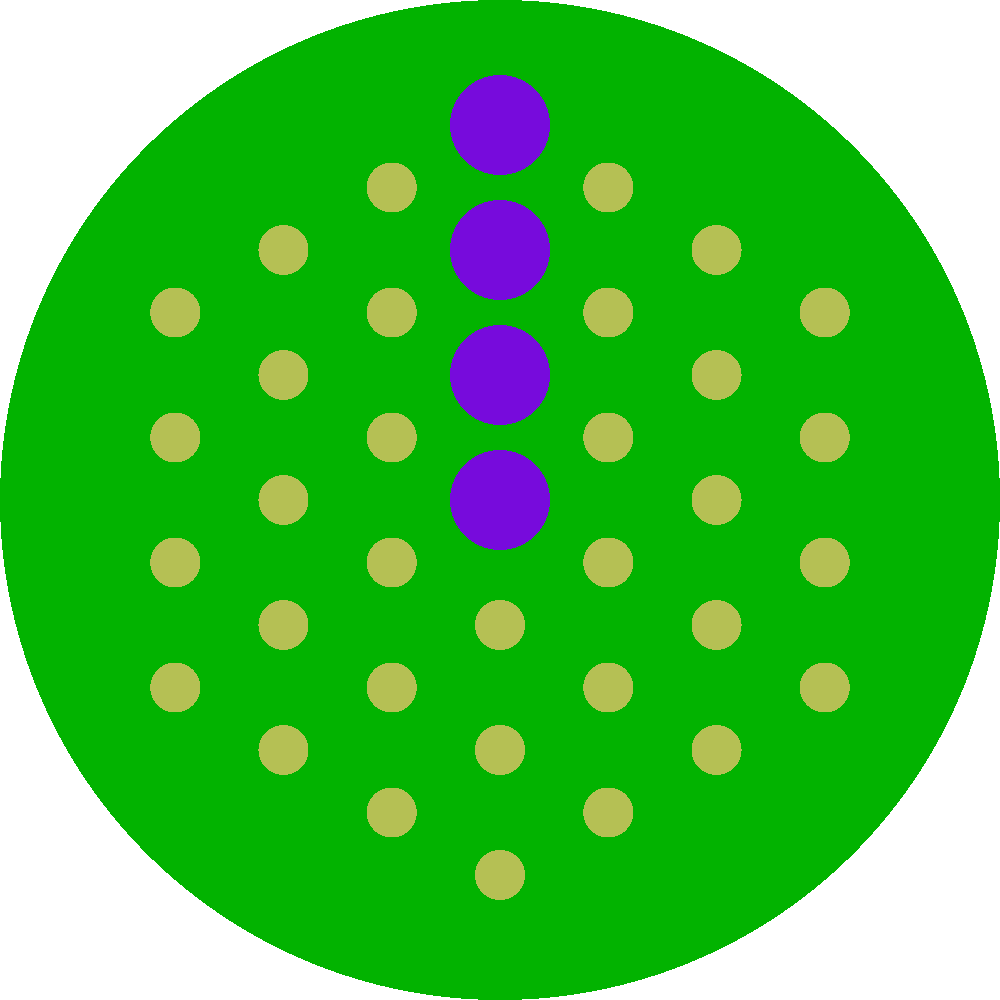

In [20]:
# Convert OpenMC's funky ppm to png
!convert geometry.ppm geometry.png

# Display the materials plot inline
Image(filename='geometry.png', width=500, height=500)